Summarize Chats using Memory & threads. AI Chat response are summarized once the threashold count of 6 chat response are reached. Use only standard routing and Node Flow.

In [91]:
# Import Python Native Lib
import os
import keyboard
from dotenv import load_dotenv

from typing import Annotated, TypedDict, Literal
from IPython.display import Image, display

# Import LangGraph & LangChain packages
from langgraph.graph import StateGraph, START, END, MessageGraph
from langgraph.graph.message import MessageGraph, add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, AnyMessage, RemoveMessage

# Import OpenAI Chat package
from langchain_openai import ChatOpenAI

# Load Env Variables
load_dotenv()


True

In [92]:
# Setup OpenAI Chat LLM

chat_llm = ChatOpenAI(model='gpt-4o', temperature=0, max_retries=2)

In [ ]:
# Define State Object and Node Functions

class State(TypedDict):
    summary: list[str]
    messages: Annotated[list[AnyMessage], add_messages]

# Summary Function 
def summarize_chat(state: State):
    msg_content = ""
    for msg in state["messages"]:
        if isinstance(msg, AIMessage):
            msg_content = msg.content
    ai_message = chat_llm.invoke('Summarize the text short paragraph of maximum 200 words.' + msg_content)
    return({"summary": ["Summary-1: " + ai_message.content]})

# Conditional Route Function
def route_to_summary(state: State) -> Literal['do_summary', END]:
    if (len(state['messages']) >= 1):
        print('Inside DO SUMMARY')
        return('do_summary')
    else:
        return(END)
    
# LLM Chat Function
def chat_with_llm(state: State):
    ai_message = chat_llm.invoke(state['messages'])
    print(ai_message)
    return({'messages': [ai_message] })


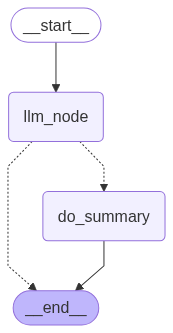

In [97]:
# Setup State Graph

graph_builder = StateGraph(State)

# Add Graph Node
graph_builder.add_node('llm_node', chat_with_llm)
graph_builder.add_node('do_summary', summarize_chat)

# Add Graph Edges
graph_builder.add_edge(START, 'llm_node')
graph_builder.add_conditional_edges('llm_node', route_to_summary)
graph_builder.add_edge('do_summary', END)

# Compile Graph
graph = graph_builder.compile()

# Visualize Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [99]:
# Test Summary of Text

print(graph.invoke({"messages": "What is a Capital of India, and what are things to see there ?"})["summary"])

content="The capital of India is New Delhi. It is a vibrant city with a rich history and a blend of modern and traditional elements. Here are some notable attractions and things to see in New Delhi:\n\n1. **India Gate**: A war memorial dedicated to the soldiers who died in World War I and the Third Anglo-Afghan War. It's a popular spot for picnics and evening strolls.\n\n2. **Rashtrapati Bhavan**: The official residence of the President of India, this grand building is an architectural marvel and is surrounded by beautiful Mughal Gardens.\n\n3. **Qutub Minar**: A UNESCO World Heritage Site, this is the tallest brick minaret in the world and is surrounded by several other ancient and medieval structures.\n\n4. **Red Fort**: Another UNESCO World Heritage Site, this historic fort was the main residence of the Mughal emperors and is a symbol of India's rich history.\n\n5. **Humayun's Tomb**: This is the tomb of the Mughal Emperor Humayun and is a stunning example of Mughal architecture, al